In [8]:
import sys
sys.path.append("/home/sam/Research/MoHCa/")
#-----
import numpy as np
import opendssdirect as dss
#-----
import mohca_cl.ga_tech.dss.model as dss_model
import mohca_cl.ga_tech.dss.qsts as dss_qsts
import mohca_cl.ga_tech.dss.sensitivity as dss_sens
import imp
imp.reload(dss_qsts)
#-----
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb}')
sns.set_theme(context='paper',style='ticks')

# Modeling Secondary Distribution Circuit Voltage Sensitivities with OpenDSS

## Step 0: Load the Three-Phase Secondary Test Circuit
### Secondary topology test case 

In [9]:
cktfile = r"/home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS"

In [10]:
time_step = '15m'
simulation_steps = 35040
qsts = dss_qsts.DSS_QSTS(redirects=cktfile,time_step=time_step,simulation_steps=simulation_steps)
Ynet,vnet = Y = qsts.get_node_ybus(True)

DSS Compiling...
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit


Text(0.5, 1.0, '$\\operatorname{Imag}(\\mathbf{Y})$')

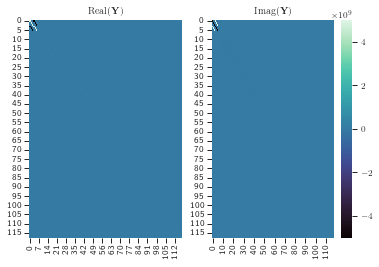

In [11]:
fig,axes = plt.subplots(ncols=2)
h1 = sns.heatmap(np.real(Ynet),ax=axes[0],center=0,cmap='mako',cbar=False)
h2 = sns.heatmap(np.imag(Ynet),ax=axes[1],center=0,cmap='mako')
axes[0].set_title(r"$\operatorname{Real}(\mathbf{Y})$")
axes[1].set_title(r"$\operatorname{Imag}(\mathbf{Y})$")

## Item 1: Construct the Voltage Sensitivity Matrices

In [12]:
sens = dss_sens.DSS_Sensitivities(cktfile,verbose=False)

DSS Compiling...
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit


In [13]:
svp = sens.get_spv()
svq = sens.get_sqv()
svp_total,svq_total=svp,svq

DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit
DSS Running file: /home/sam/research/mohca_cl/mohca_cl/ga_

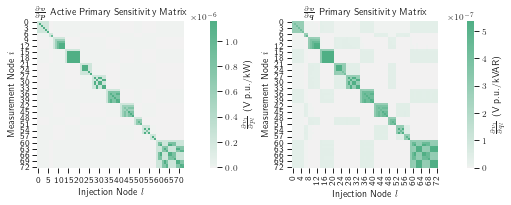

In [14]:
#Plot overall matrix
start_idx = 45 #Bus idx to start plot from
fig,axes = plt.subplots(ncols=2,constrained_layout=True,figsize=(7,7/1.62828))

#cbar_ax = fig.add_axes([.89, .3, .02, .4])
pal = sns.diverging_palette(30, 150, l=65, center="light", as_cmap=True)
#plt.suptitle("Secondary Topology Test Network (STN) Primary Sensitivity Matrices")
axes[0].set_title(r"$\frac{\partial \boldsymbol{v}}{\partial \boldsymbol{p}}$ Active Primary Sensitivity Matrix")
axes[1].set_title(r"$\frac{\partial \boldsymbol{v}}{\partial \boldsymbol{q}}$ Primary Sensitivity Matrix")

sns.heatmap(svp["matrix"][start_idx:,start_idx:],
    square=True,
    ax = axes[0],
    robust=True,
    center=0,
    linewidths=0.0005,
    linecolor='black',
    cmap=pal,
    #xticklabels=3,
    #yticklabels=3,
    cbar_kws= {
        'shrink':1,
        'fraction':0.05,
        'label':r"$\frac{\partial v_i}{\partial p_l}$ (V p.u./kW)",
        'drawedges':False
    }, 
    rasterized=True
)

sns.heatmap(svq["matrix"][start_idx:,start_idx:],
    square=True,
    ax = axes[1],
    robust=True,
    center=0,
    linewidths=0.0005,
    linecolor='black',
    cmap=pal,
    #xticklabels=3,
    #yticklabels=3,
    cbar_kws= {
        'shrink':1,
        'fraction':0.05,
        'label':r'$\frac{\partial v_i}{\partial q_l}$ (V p.u./kVAR)',
        'drawedges':False
    }, 
    rasterized=True
)
for ax in axes:
    ax.set_xlabel(r"Injection Node $l$")
    ax.set_ylabel(r"Measurement Node $i$")

#plt.savefig("/home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/Figures_Secondary/modified_primary_S.pdf",dpi=400)
#plt.savefig("/home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/Figures_Secondary/modified_primary_S.png",dpi=400)


In [15]:
print(dss.Circuit.AllNodeNames())

['bussource.1', 'bussource.2', 'bussource.3', 'mdv_sub_1_hsb.1', 'mdv_sub_1_hsb.2', 'mdv_sub_1_hsb.3', 'feederheadbus.1', 'feederheadbus.2', 'feederheadbus.3', 'busprim1.1', 'busprim1.2', 'busprim1.3', 'busprim2.1', 'busprim2.2', 'busprim2.3', 'busprim3.1', 'busprim3.2', 'busprim3.3', 'busprim4.1', 'busprim4.2', 'busprim4.3', 'busprim5.1', 'busprim5.2', 'busprim5.3', 'busprim6.1', 'busprim6.2', 'busprim6.3', 'busprim7.1', 'busprim7.2', 'busprim7.3', 'busprim8.1', 'busprim8.2', 'busprim8.3', 'busprim9.1', 'busprim9.2', 'busprim9.3', 'busprim10.1', 'busprim10.2', 'busprim10.3', 'busprim11.1', 'busprim11.2', 'busprim11.3', 'busprim12.1', 'busprim12.2', 'busprim12.3', 'bustrafo1lv.1', 'bussec1_1.1', 'bussec1_2.1', 'bussec1_3.1', 'bussec1_4.1', 'bussec1_5.1', 'bustrafo2lv.2', 'bussec2_1.2', 'bustrafo3lv.3', 'bussec3_1.3', 'bussec3_2.3', 'bussec3_3.3', 'bussec3_4.3', 'bussec3_5.3', 'bustrafo4lv.1', 'bussec4_0.1', 'bussec4_1.1', 'bussec4_2.1', 'bussec4_3.1', 'bussec4_4.1', 'bussec4_5.1', 'bus

In [20]:
names = np.asarray(dss.Circuit.AllNodeNamesByPhase(Phase=3))
sec_names = []
for name in names:
    if "sec" in name:
        sec_names.append(name)
    if "trafo" in name:
        sec_names.append(name)
sec_names


['bustrafo3lv.3',
 'bussec3_1.3',
 'bussec3_2.3',
 'bussec3_3.3',
 'bussec3_4.3',
 'bussec3_5.3',
 'bustrafo5lv.3',
 'bussec5_0.3',
 'bussec5_1.3',
 'bussec5_2.3',
 'bussec5_3.3',
 'bussec5_4.3',
 'bustrafo6lv.3',
 'bussec6_01.3',
 'bussec6_02.3',
 'bussec6_1.3',
 'bussec6_2.3',
 'bussec6_3.3',
 'bussec6_4.3',
 'bustrafo9lv.3',
 'bussec9_0.3',
 'bussec9_1.3',
 'bussec9_2.3']

In [40]:
def make_secondary_slices(n_secondaries = 12):
    """
    Make slices of the node indexes of the currently loaded opendss feeder mapping to the secondary networks
    Params:
        n_secondaries: Number of secondary groups in the feeder
    """
    
    #Secondaries results dictionary
    secondaries = {}

    #Node names and node names by phase    
    node_names = dss.Circuit.AllNodeNames()
    a_node_names,b_node_names,c_node_names = dss.Circuit.AllNodeNamesByPhase(Phase=1),dss.Circuit.AllNodeNamesByPhase(Phase=2),dss.Circuit.AllNodeNamesByPhase(Phase=3)

    #Secondary indeces
    secondary_names = [str(i) for i in range(1,n_secondaries+1)] #Group index of the secondary names
    
    for sec_name in secondary_names:
        sec_bus_idx = 1 #Counter for the bus number within the secondary
        node_idxs_in_sec,node_names_in_sec = [],[] 
        
        for node_idx,node_name in enumerate(node_names):

            #Collect the phase info
            if(node_name in a_node_names):
                phase = 'a'
            elif(node_name in b_node_names):
                phase = 'b'
            elif(node_name in c_node_names):
                phase = 'c'
            else:
                print("no phase for: {node_name}".format(node_name=node_name))
                phase = ""

            if('sec' + sec_name + "_" in node_name): #Hacky way to separate by node name
                node_idxs_in_sec.append(node_idx)
                node_names_in_sec.append('s' + sec_name + "_" + str(sec_bus_idx) + "_"+phase)
                #Increment the secondary bus index counter
                sec_bus_idx += 1
            elif("trafo" + sec_name + "lv" in node_name): #Catch low voltage transformers
                node_idxs_in_sec.append(node_idx)
                node_names_in_sec.append('s' + sec_name + "_" + "xfmrlv"+ "_"+phase)
        secondaries['sec' + sec_name] = {
            "node_idxs":node_idxs_in_sec,
            "node_names":node_names_in_sec
        }
    return secondaries         


In [41]:
names[-14:]

['xfmrlv.1',
 'buslv1.1',
 'buslv2.1',
 'buslv3.1',
 'buslv4.1',
 'buslv5.1',
 'busload1.1',
 'busload2.1',
 'busload3.1',
 'busload4.1',
 'busload5.1',
 'busload6.1',
 'busload7.1',
 'busload8.1']

In [42]:
secondaries = make_secondary_slices()
secondaries

{'sec1': {'node_idxs': [45, 46, 47, 48, 49, 50],
  'node_names': ['s1_xfmrlv_a',
   's1_1_a',
   's1_2_a',
   's1_3_a',
   's1_4_a',
   's1_5_a']},
 'sec2': {'node_idxs': [51, 52], 'node_names': ['s2_xfmrlv_b', 's2_1_b']},
 'sec3': {'node_idxs': [53, 54, 55, 56, 57, 58],
  'node_names': ['s3_xfmrlv_c',
   's3_1_c',
   's3_2_c',
   's3_3_c',
   's3_4_c',
   's3_5_c']},
 'sec4': {'node_idxs': [59, 60, 61, 62, 63, 64, 65],
  'node_names': ['s4_xfmrlv_a',
   's4_1_a',
   's4_2_a',
   's4_3_a',
   's4_4_a',
   's4_5_a',
   's4_6_a']},
 'sec5': {'node_idxs': [66, 67, 68, 69, 70, 71],
  'node_names': ['s5_xfmrlv_c',
   's5_1_c',
   's5_2_c',
   's5_3_c',
   's5_4_c',
   's5_5_c']},
 'sec6': {'node_idxs': [72, 73, 74, 75, 76, 77, 78],
  'node_names': ['s6_xfmrlv_c',
   's6_1_c',
   's6_2_c',
   's6_3_c',
   's6_4_c',
   's6_5_c',
   's6_6_c']},
 'sec7': {'node_idxs': [79, 80, 81, 82, 83, 84, 85],
  'node_names': ['s7_xfmrlv_a',
   's7_1_a',
   's7_2_a',
   's7_3_a',
   's7_4_a',
   's7_5_a',
 

## Item 2: Construct secondary matrices of varying topoologies FOR THE MODIFIED NETWORK

In [43]:
#Make secondary submatrices
import pandas as pd
secondaries = make_secondary_slices()

#Note: hard code catch to catch the final subnetwork
names = dss.Circuit.AllNodeNames()
n_nodes = len(names)
sec_12_node_names = names[-14:]
n_nodes_sec_12 = len(sec_12_node_names)

sec_bus_idx = 1 #Counter for the bus number within the secondary
#Final sec12 network idxs
sec_12_node_idxs,formatted_sec_12_node_names = [],[]
for node_idx,node_name in enumerate(names):
    if(node_name in sec_12_node_names):
        sec_12_node_idxs.append(node_idx)
        if("xfmr" not in node_name):
            formatted_sec_12_node_names.append('s12_' + str(sec_bus_idx) + "_a")
            sec_bus_idx+=1
        else:
            formatted_sec_12_node_names.append("s12_xfmrlv_a")
secondaries["sec12"] = {
    'node_idxs':sec_12_node_idxs,
    'node_names':formatted_sec_12_node_names
}

In [44]:
secondaries['sec12']

{'node_idxs': [104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117],
 'node_names': ['s12_xfmrlv_a',
  's12_1_a',
  's12_2_a',
  's12_3_a',
  's12_4_a',
  's12_5_a',
  's12_6_a',
  's12_7_a',
  's12_8_a',
  's12_9_a',
  's12_10_a',
  's12_11_a',
  's12_12_a',
  's12_13_a']}

/tmp/ipykernel_357/685216823.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .875, 1])
/tmp/ipykernel_357/685216823.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .875, 1])


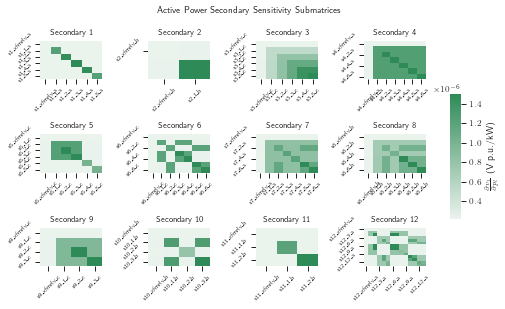

<Figure size 432x288 with 0 Axes>

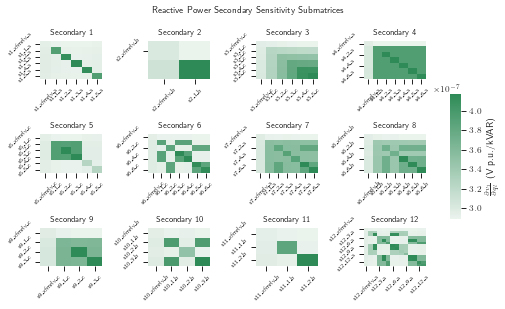

<Figure size 432x288 with 0 Axes>

In [68]:



svp0,svq0 = svp['matrix'],svq['matrix']

for S,suptitle,cbar_label in zip(
    [svp0,svq0],
    ["Active Power Secondary Sensitivity Submatrices","Reactive Power Secondary Sensitivity Submatrices"],
    [r'$\frac{\partial v_i}{\partial p_l}$ (V p.u./kW)',r'$\frac{\partial v_i}{\partial q_l}$ (V p.u./kVAR)']):
    
    
    #Make figure parameters
    #fig = plt.figure(figsize=(3*3.5,(2*3.5)/1.61828))
    fig,axes = plt.subplots(
        nrows=3,ncols=4,
        figsize=(2*3.5,(2*3.5)/1.61828),
        )
    #fig.subplots_adjust(hspace=0.55,wspace=0.45)


    #(nrows,ncols,plot_number)
    #subplot_params = [(3,4,1),(3,4,2),(3,4,3),(3,4,4),(3,4,5),(3,4,6),(3,4,7),(3,4,8),(3,5,12),(3,5,13),(3,5,14)]

    #Colorbar
    cbar_ax = fig.add_axes([.9, .3, .02, .4])
    #pal = sns.diverging_palette(30, 150, l=65, center="light", as_cmap=True)
    pal = sns.light_palette("seagreen", as_cmap=True)
    plt.suptitle(suptitle,fontsize=9)


    
    for i,(sec_name,d) in enumerate(secondaries.items()):
        #nrows,ncols,plot_number = subplot_params[i]

        #Setup axis of the subplot
        #ax = fig.add_subplot(nrows,ncols,plot_number)
        ax = axes.flatten()[i]
       
        #Make axis labels
        node_idxs = d["node_idxs"]
        node_names = d["node_names"]
        
        #Make dataframe
        S_sec = S[np.ix_(node_idxs,node_idxs)]
        S_sec = pd.DataFrame(S_sec,index=node_names,columns=node_names)
        h = sns.heatmap(
            S_sec,
            #vmax=17e-7,
            #vmin=0,
            robust=True,
            #center=0,
            linewidths=0.0015,
            linecolor='black',
            cmap=pal,
            cbar= i == 0,
            xticklabels= 3 if i == 11 else "auto",
            yticklabels = 3 if i ==1 else "auto",
            cbar_ax= cbar_ax,
            cbar_kws= None if i else {
                'shrink':1,
                'fraction':0.05,
                'label':cbar_label,
                'drawedges':False
            }, 
            ax = ax,
            rasterized=True
        )
        h.set_yticklabels(h.get_yticklabels(), rotation = 45, fontsize = 6)
        h.set_xticklabels(h.get_xticklabels(), rotation=45, fontsize=6)
        ax.set_title("Secondary {i}".format(i=i+1),fontsize=8)
    
    #Tight layout
    plt.tight_layout(rect=[0, 0, .875, 1])
    #Save figures
    plt.savefig("/home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/Figures_Secondary/12sec_"+suptitle[:6]+".pdf",dpi=400)
    plt.savefig("/home/sam/research/mohca_cl/mohca_cl/ga_tech/secondary/Figures_Secondary/12sec_"+suptitle[:6]+".png",dpi=400)
    plt.figure()

## Compare the Eigenvalues of the Secondaries

In [215]:
eigs_tot = np.linalg.eigvals(svp0)
for i,(sec_name,d) in enumerate(secondaries.items()):
    S = d["S"]
    eigmax = lambda A: np.max(np.abs(np.linalg.eigvals(A)))
    eigvals = np.linalg.eigvals(S)
    #print(eigvals)
    print(eigmax(S))
    

2.724913177586415e-06
7.173509290614301e-07
4.440954638739481e-06
5.449983528264108e-06
4.228659962094999e-06
4.775820426908749e-06
5.665176426215392e-06
6.694889328200497e-06
2.5360173183645946e-06
2.4774575873171926e-06


In [147]:
np.max(svq0[33:,33:])

1.2450844427775109e-06

In [216]:
M = len(vnet)
N = Ynet.shape[0]
r,x = [],[]
for i,y_i in enumerate(Ynet):
    for j, y_ij in enumerate(y_i):
        if j<i and abs(y_ij)>0:
            r.append(np.real(y_ij))
            x.append(np.imag(y_ij))


In [217]:
def lower_offidag_nonzero(M):
    """
    Construct a vector of the nonzero elements of the lower offdiagonal portion of the matrix M
    """
    elements = []
    for i,m_i in enumerate(M):
        for j, m_ij in enumerate(m_i):
            if j<i and abs(m_ij)>0:
                elements.append(m_ij)
    return np.array(elements)

def get_impedance_matrix(Y):
    X,R = np.zeros_like(Y),np.zeros_like(Y)
    for i,y_i in enumerate(Y):
        for j, y_ij in enumerate(y_i):
            if j<i and abs(y_ij)>0:
                z_ij = 1/y_ij
                X[i,j] = np.real(z_ij)
                R[i,j] = np.imag(z_ij)
    return X + R*j

def get_line_impedances(Y):
    """
    Construct a vector of the nonzero elements of the lower offdiagonal portion of the bus admittance matrix Y
    This results int he line impedances
    """
    Z = get_impedance_matrix(Y)
    X,R = np.real(Z),np.imag(Z)
    xs,rs = lower_offidag_nonzero(X),lower_offidag_nonzero(R)
    return xs,rs


In [150]:
Znet = get_impedance_matrix(Ynet)

In [156]:
xs,rs = get_line_impedances(Ynet)

In [152]:
#Upper and lower off-diagonal elements
def U(A):
    u = []
    for i,ai in enumerate(A):
        for j,aij in enumerate(ai):
            if (i>j):
                u.append(aij)
    return u

def L(A):
    l = []
    for i,ai in enumerate(A):
        for j,aij in enumerate(ai):
            if (i<j):
                l.append(aij)
    return l
def is_radial(Y):  
    n = Y.shape[0]
     
    
    #Get the nonzero upper and lower off diagonal elements
    nz_upper = [1 for y_ij in U(Y) if y_ij != 0]
    nz_lower = [1 for y_ij in L(Y) if y_ij != 0]
    nnnz_u,nnz_l = np.sum(nz_upper),np.sum(nz_lower)
    print(nnnz_u,nnz_l)
    is_not_radial = np.sum(nz_upper)>n-1 or np.sum(nz_lower) >n-1
    is_radial = not(is_not_radial)
    return is_radial


In [154]:
import cvxpy as cp
sens.compile_dss(cktfile)
sens.dss.run_command("solve")
i = sens.get_node_currents()
v = sens.get_node_voltages()

DSS Running file: /home/sam/github/PowerSensitivities.jl/data/secondary_test_circuit/compileCircuit.dss


In [155]:
s = []
p = []
q = []
vmsq = []
for k,(name,current) in enumerate(i.items()):
    s.append( v[name]*np.conjugate(current))
    p.append(np.real(v[name]*np.conjugate(current)))
    q.append(np.imag(v[name]*np.conjugate(current)))
    vmsq.append(np.abs(v[name])**2)
vmsq,p,q = np.array(vmsq),np.array(p),np.array(q)
s = np.array(s)

## Item 3: Case 3 variants

In [196]:
case3_unbalanced = r"/home/sam/Research/yadi/test_cases/case3_unbalanced.dss"
case3_unbalanced_delta = r"/home/sam/Research/yadi/test_cases/case3_unbalanced_delta_loads.dss"
case3_unbalanced_1ph = r"/home/sam/Research/yadi/test_cases/case3_unbalanced_1phase-pv.dss"

In [182]:
case3 = {}
for name,cktfile in zip(["std","delta","1phpv"],[case3_unbalanced,case3_unbalanced_delta,case3_unbalanced_1ph]):
    sens = dss_sens.OpenDSS_Sensitivities(cktfile,verbose=False)
    Ynet,vnet = Y = sens.get_node_ybus(True)
    svp = sens.get_spv()
    svq = sens.get_sqv()
    svp0,svq0 = svp['matrix'],svq['matrix']
    nodes,vbase = svp["nodes"],svp["vph_base"]
    #Store results
    case3[name] = {
        "Y":Ynet,
        "vnet":vnet,
        "vbase":vbase,
        "svp":svp0,
        "svq":svq0,
        "is_radial":is_radial(Ynet)
    }

DSS Compiling...
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /home/sam/Research/yadi/test_cases/case3_unbalanced.dss
DSS Running file: /ho

In [183]:
case3['std']['Y'][:,3]

array([-9.67251619 +5.64153314j,  2.76271697 -1.61235288j,
        2.76271697 -1.61235288j, 18.04780485-10.42764029j,
       -5.15665908 +2.98007587j, -5.15665908 +2.98007587j,
       -8.37528866 +4.78612316j,  2.39394211 -1.367723j  ,
        2.39394211 -1.367723j  ])